# Early Warning System — Supervised Models

---

## Objective and Theoretical Framework

Build a supervised **Early Warning System (EWS)** to detect anomalous market periods (*risk-off*), leveraging the labels available in the dataset to learn the financial signature of crises.

### Taxonomy of Crises (Sornette, 2009)

An early warning system involves three structurally different problems that require different architectures:

| Type | Mechanism | Example | Predictable? | Optimal Approach |
|---|---|---|---|---|
| **Black Swan** | Exogenous shock | Covid-2020 | **No** — absent in historical time series | Change-point detection |
| **Dragon King** | Endogenous feedback | GFC-2008, dot-com 2001 | **Yes** — the signal is in the historical series | Supervised with temporal features |
| **Anti-bubble** | Boom/crash symmetry | Bull market 1999, 2017 | Partially | Directional labels |

**Supervised models are structurally advantaged for Dragon Kings** for two reasons:

1. **Labels encode directionality** — the model learns that VIX↑ + equity↓ = risk-off, not just that it is statistically unusual. Unsupervised models, by construction, do not distinguish between crises and extreme booms.
2. **Temporal features capture endogenous build-up** — Filimonov & Sornette (2012) show that before Dragon Kings, the branching ratio $n \to 1$: self-generated activity grows for months. The observable signature consists of rising HY spreads, a flattening yield curve, and increasing interbank rates — signals that require a time horizon to be encoded.

The **Black Swan crisis** remains by definition unpredictable by any model trained on past historical series — the signal does not exist before the event.

### Pipeline

1. Data loading
2. Stationarity transformation
3. Temporal feature engineering — Dragon King signals
4. Train/CV/test split, shuffle, and standardization
5. Baseline models — Random Forest, SVM
6. Imbalance management — SMOTE, cost-sensitive XGBoost
7. Hyperparameter optimization with Optuna
8. Analysis — SHAP, temporal analysis
9. Conclusions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = [10, 6]

np.random.seed(42)

## Data Loading

We load the dataset from Excel, set the `Date` column as the temporal index, and separate the features `X` from the target variable `y`.

- `X` contains the 42 financial variables (equity indices, rates, currencies, commodities, VIX)
- `y` is the binary vector of labels (0 = normal, 1 = risk-off/anomaly)
- The dataset covers **weekly** data from January 18, 2000, to April 20, 2021 (1111 observations, ~21% anomalies)

In [2]:
from pathlib import Path as _P

def _find_dataset():
    for p in [_P.cwd(), *_P.cwd().parents]:
        c = p / 'data' / 'Dataset4_EWS.xlsx'
        if c.exists():
            return c
    raise FileNotFoundError("Dataset4_EWS.xlsx not found in data/ (searched up to root)")

file_path = _find_dataset()
print(f'Dataset: {file_path}')

data_df = pd.read_excel(file_path, sheet_name='Markets')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

date_col = 'Date' if 'Date' in data_df.columns else data_df.columns[0]
y_col = 'Y' if 'Y' in data_df.columns else None

data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)
data_df = data_df.set_index(date_col)

if y_col:
    X_df = data_df.drop(y_col, axis=1)
    y = data_df[y_col].values
else:
    X_df = data_df
    y = None

print(f"Data shape: {X_df.shape}")
print(f"Total anomalies in raw data: {np.sum(y == 1)} ({np.mean(y == 1)*100:.2f}%)")

_ROOT = _find_dataset().parent.parent

Dataset: /Users/simonezani/Documents/github/fintech-group-work/BusinessCase4/data/Dataset4_EWS.xlsx


Data shape: (1111, 42)
Total anomalies in raw data: 237 (21.33%)


## Stationarity Transformation

Financial time series are non-stationary — prices grow over time and their mean/variance change. We apply different transformations depending on the variable type:

| Type | Transformation | Rationale |
|---|---|---|
| Indices and currencies (23 features) | Log-difference: $\log(P_t) - \log(P_{t-1})$ | Always positive, multiplicative growth |
| Interest rates (18 features) | First difference: $r_t - r_{t-1}$ | Can be negative |
| ECSURPUS (1 feature) | As-is | Already stationary by construction |

> The transformation does not estimate global parameters — it does not introduce data leakage.
> `np.diff()` removes the first observation: from 1111 to **1110 observations**.

In [3]:
indices_currencies = [col for col in X_df.columns if col in [
    'XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU',
    'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU',
    'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'VIX'
]]

interest_rates = [col for col in X_df.columns if col in [
    'EONIA', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y',
    'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR',
    'US0001M', 'USGG3M', 'USGG2YR', 'GT10', 'USGG30YR'
]]

stationary_df = pd.DataFrame(index=X_df.index[1:])

for col in indices_currencies:
    if col in X_df.columns:
        stationary_df[col] = np.diff(np.log(X_df[col]))

for col in interest_rates:
    if col in X_df.columns:
        stationary_df[col] = np.diff(X_df[col])

if 'ECSURPUS' in X_df.columns:
    stationary_df['ECSURPUS'] = X_df['ECSURPUS'].values[1:]

y_stationary = y[1:] if y is not None else None

print(f"Stationary dataset shape: {stationary_df.shape}")

Stationary dataset shape: (1110, 42)


## Temporal Feature Engineering

A model using only point-in-time snapshots cannot capture the *build-up* of endogenous crises. Filimonov & Sornette (2012) show that before Dragon Kings, the branching ratio $n \to 1$: self-generated activity grows for weeks/months. The observable signature consists of rising HY spreads, a flattening yield curve, and increasing interbank rates — all signals over 3-6 month horizons.

We add temporal features **before shuffling**, so that each observation carries its own historical context:

| Feature | Formula | Dragon King Signal |
|---|---|---|
| `{col}_mom{h}w` | $\sum(r_{t-h+1}, \dots, r_t)$ | Cumulative momentum — rising HY spreads before Lehman |
| `{col}_vol{h}w` | $\text{std}(r_{t-h+1}, \dots, r_t)$ | Realized volatility — expanding stress regime |
| `YC_US`, `YC_DE` | 10Y − 2Y (level) | Inverted curve = recessionary signal (US inversion in 2006, 18 months before Lehman) |

**Monitored assets:** VIX, LF98TRUU (HY spread), DXY, XAUBGNL (gold), EONIA, US0001M, MXUS, MXEU  
**Horizons:** 12w (~3 months) and 26w (~6 months) — consistent with the LPPL literature (Johansen, Ledoit & Sornette, 2000)

> **Methodological Note:** rolling windows create temporal dependence between consecutive observations.
> After shuffling, observations with partially overlapping windows can end up in both train and test sets — a form of limited leakage. In a real-world deployment, one would use time-series cross-validation without shuffling.

In [4]:
# Dragon King temporal features — Sornette/Filimonov buildup signals
# Computed BEFORE shuffle: temporal context encoded as observation attributes

horizons = [12, 26]  # 12w ≈ 3 months | 26w ≈ 6 months (LPPL buildup range)

stress_cols = [c for c in ['VIX', 'LF98TRUU', 'DXY', 'XAUBGNL', 'EONIA', 'US0001M'] if c in stationary_df.columns]
equity_cols = [c for c in ['MXUS', 'MXEU'] if c in stationary_df.columns]

temporal_features = stationary_df.copy()

for col in stress_cols + equity_cols:
    for h in horizons:
        temporal_features[f'{col}_mom{h}w'] = temporal_features[col].rolling(h).sum()
        temporal_features[f'{col}_vol{h}w'] = temporal_features[col].rolling(h).std()

# Yield curve slope LEVEL (not differenced) — key Dragon King signal
# GFC: US 10Y-2Y inverted in 2006, ~18 months before Lehman
if 'GT10' in X_df.columns and 'USGG2YR' in X_df.columns:
    temporal_features['YC_US'] = (X_df['GT10'] - X_df['USGG2YR']).values[1:]

if 'GTDEM10Y' in X_df.columns and 'GTDEM2Y' in X_df.columns:
    temporal_features['YC_DE'] = (X_df['GTDEM10Y'] - X_df['GTDEM2Y']).values[1:]

# Drop NaN rows from rolling windows (max horizon = 26 → first 25 rows removed)
temporal_features = temporal_features.dropna()
y_temporal = y_stationary[len(y_stationary) - len(temporal_features):]

n_new = temporal_features.shape[1] - stationary_df.shape[1]
print(f"Total features: {temporal_features.shape[1]} (original: {stationary_df.shape[1]}, new temporal: {n_new})")
print(f"Observations: {temporal_features.shape[0]} ({stationary_df.shape[0] - temporal_features.shape[0]} removed for rolling windows)")
print(f"Anomalies: {np.sum(y_temporal==1)} / {len(y_temporal)} ({np.mean(y_temporal)*100:.1f}%)")


Total features: 76 (original: 42, new temporal: 34)
Observations: 1085 (25 removed for rolling windows)
Anomalies: 229 / 1085 (21.1%)


## Split, Shuffle, and Standardization

The same protocol as the unsupervised notebook:

| Set | Composition | Notes |
|---|---|---|
| `X_train` | 80% of normal | Normal only — base for the scaler |
| `X_cross_val` | 10% of normal + 50% of anomalies | Used as supervised training along with X_train |
| `X_test` | 10% of normal + 50% of anomalies | Held-out for the final evaluation |

The **StandardScaler** is fitted exclusively on `X_train` and then applied to CV and test sets — ensuring no information leakage from the test set.

The datasets are shuffled before splitting to break temporal autocorrelation. The temporal features preserve the historical context of each observation as an attribute, regardless of the sample order.

In [5]:
X = temporal_features.values
y = y_temporal

# Reshuffle to break temporal autocorrelation
X_shuffled, y_shuffled = shuffle(X, y, random_state=42)

# Separate classes
X_normal = X_shuffled[y_shuffled == 0]
X_anomaly = X_shuffled[y_shuffled == 1]

n_normal = X_normal.shape[0]
n_anomaly = X_anomaly.shape[0]

# Splits: Train (80% normal), CV (10% normal + 50% anomaly), Test (10% normal + 50% anomaly)
train_size = int(0.8 * n_normal)
X_train = X_normal[:train_size]

cv_normal_size = int(0.1 * n_normal)
cv_anomaly_size = int(0.5 * n_anomaly)
X_cv_normal = X_normal[train_size:train_size + cv_normal_size]
X_cv_anomaly = X_anomaly[:cv_anomaly_size]
X_cross_val = np.vstack((X_cv_normal, X_cv_anomaly))
y_cross_val = np.hstack((np.zeros(cv_normal_size), np.ones(cv_anomaly_size)))

X_test_normal = X_normal[train_size + cv_normal_size:]
X_test_anomaly = X_anomaly[cv_anomaly_size:]
X_test = np.vstack((X_test_normal, X_test_anomaly))
y_test = np.hstack((np.zeros(len(X_test_normal)), np.ones(len(X_test_anomaly))))

# Scaler fit only on training data (no leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_cv_scaled = scaler.transform(X_cross_val)
X_test_scaled = scaler.transform(X_test)

# Combined training set for supervised learning (Train + Cross Validation)
X_train_cv = np.vstack((X_train_scaled, X_cv_scaled))
y_train_cv = np.hstack((np.zeros(len(X_train_scaled)), y_cross_val))

# Feature names for SHAP and temporal analysis
feature_names = temporal_features.columns.tolist()

print(f"Supervised Train Set: {X_train_cv.shape[0]} obs ({np.sum(y_train_cv==0):.0f} normal, {np.sum(y_train_cv==1):.0f} anomalies)")
print(f"Supervised Test Set:  {X_test_scaled.shape[0]} obs ({np.sum(y_test==0):.0f} normal, {np.sum(y_test==1):.0f} anomalies)")
print(f"Total features in the model: {X_train_cv.shape[1]}")


Supervised Train Set: 883 obs (769 normal, 114 anomalies)
Supervised Test Set:  202 obs (87 normal, 115 anomalies)
Total features in the model: 76


In [6]:
# Setup metric tracking framework
results = []

def evaluate_model(y_true, y_pred, y_score, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
    else:
        roc_auc = np.nan

    print(f"--- {model_name} Performance ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    if y_score is not None:
        print(f"ROC AUC:   {roc_auc:.4f}")
    print("-" * 35)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Anomaly'], 
                yticklabels=['Normal', 'Anomaly'], ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'Confusion Matrix - {model_name}')

    if y_score is not None:
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'ROC Curve - {model_name}')
        axes[1].legend(loc="lower right")
    else:
        axes[1].text(0.5, 0.5, 'ROC Curve Not Available', ha='center', va='center', fontsize=14)
        axes[1].axis('off')
        
    plt.tight_layout()
    plt.show()

    return precision, recall, f1, roc_auc

## Baseline Models

We train the two reference models with class weight balancing (`class_weight='balanced'`) to handle the ~79/21 class imbalance. Both are trained on the combined Train + CV set.

### Evaluation Metrics

- **Precision** — out of all points classified as risk-off, how many were actually crises
- **Recall** — out of all actual crises in the test set, how many were detected
- **F1 Score** — main metric: harmonic mean of Precision and Recall
- **ROC AUC** — ability to separate normal periods from anomalies regardless of the threshold

> In a **risk management** context, Recall is the most critical metric: a missed crisis is far more costly than a false alarm.

Training Random Forest Baseline...


--- Random Forest Baseline Performance ---
Precision: 1.0000
Recall:    0.3391
F1 Score:  0.5065
ROC AUC:   0.9180
-----------------------------------


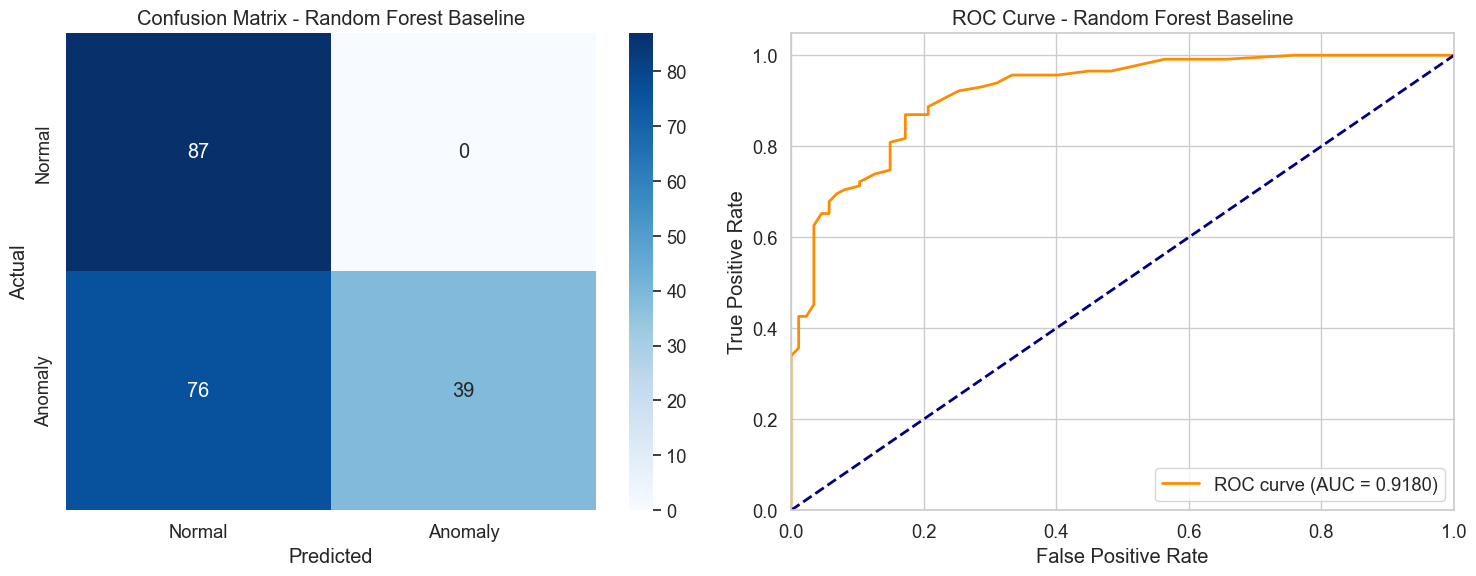

In [7]:
print("Training Random Forest Baseline...")
rf_base = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_base.fit(X_train_cv, y_train_cv)

rf_base_pred = rf_base.predict(X_test_scaled)
rf_base_score = rf_base.predict_proba(X_test_scaled)[:, 1]

rf_base_metrics = evaluate_model(y_test, rf_base_pred, rf_base_score, "Random Forest Baseline")
results.append(("Random Forest Baseline", *rf_base_metrics))

Training SVM Baseline...


--- SVM Baseline Performance ---
Precision: 0.8506
Recall:    0.6435
F1 Score:  0.7327
ROC AUC:   0.8672
-----------------------------------


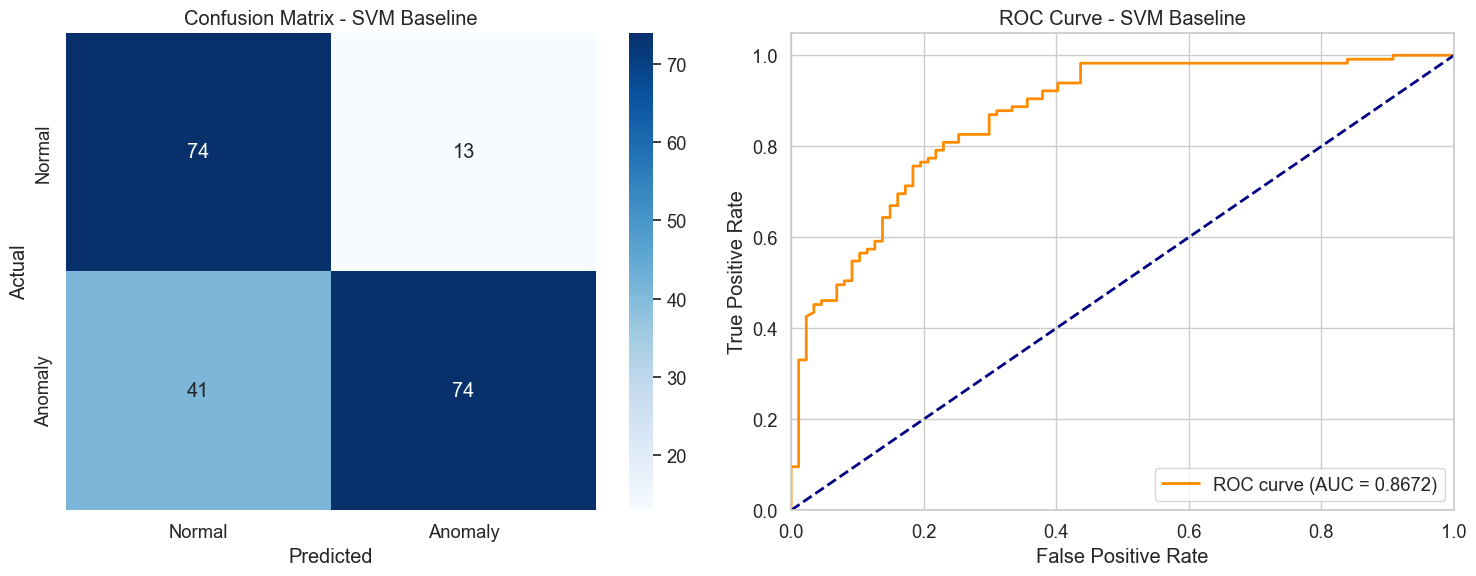

In [8]:
print("Training SVM Baseline...")
svm_base = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_base.fit(X_train_cv, y_train_cv)

svm_base_pred = svm_base.predict(X_test_scaled)
svm_base_score = svm_base.predict_proba(X_test_scaled)[:, 1]

svm_base_metrics = evaluate_model(y_test, svm_base_pred, svm_base_score, "SVM Baseline")
results.append(("SVM Baseline", *svm_base_metrics))

## Imbalance Management

The baselines with `class_weight='balanced'` yield high Precision but low Recall — the model is too conservative in signaling anomalies. We test two strategies:

**SMOTE** (Synthetic Minority Over-sampling Technique): generates synthetic observations of the minority class by interpolating between real anomalies close to each other in the feature space. It balances the training set before training the model.

**scale_pos_weight (XGBoost)**: penalizes errors on the minority class during gradient boosting optimization without modifying the data. Optimal weight: `n_normal / n_anomaly`.

Expected trade-off: higher Recall, lower Precision — which is highly acceptable in risk management.

Applying SMOTE on Supervised Training Set...
Oversampled training set size: 1538 (normal=769, anomaly=769)
Training Random Forest + SMOTE...


--- Random Forest + SMOTE Performance ---
Precision: 0.9324
Recall:    0.6000
F1 Score:  0.7302
ROC AUC:   0.9213
-----------------------------------


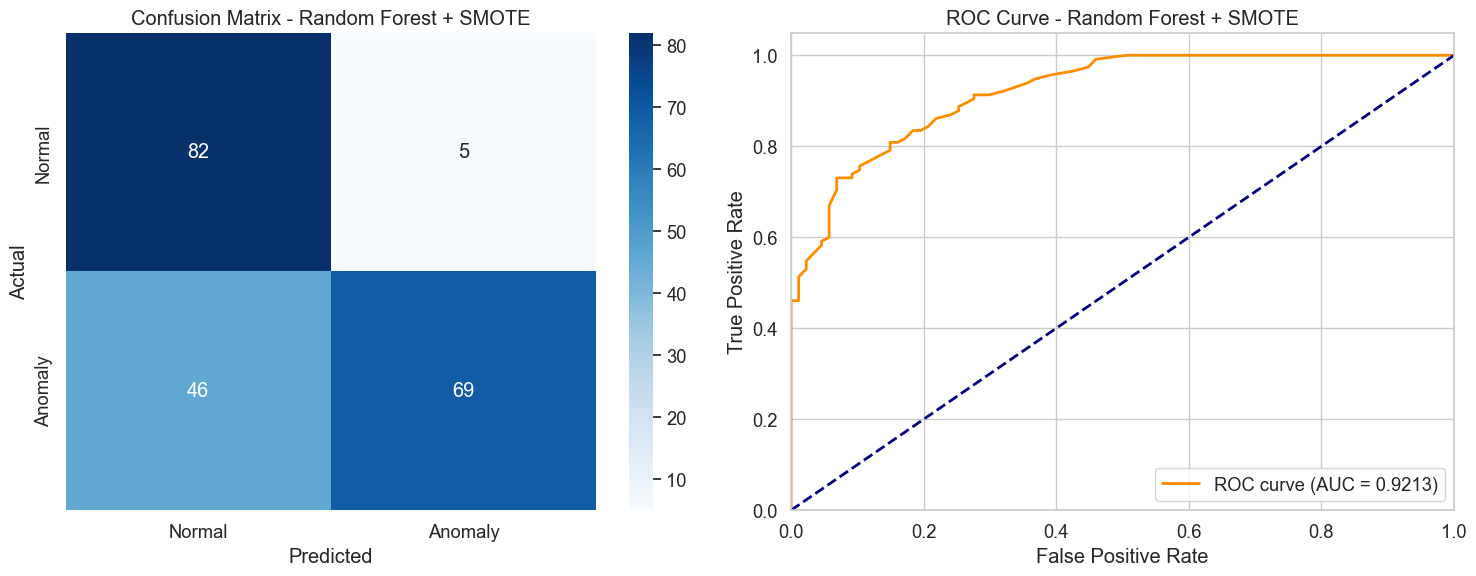

In [9]:
from imblearn.over_sampling import SMOTE

print("Applying SMOTE on Supervised Training Set...")
smote = SMOTE(random_state=42)
X_train_cv_res, y_train_cv_res = smote.fit_resample(X_train_cv, y_train_cv)

print(f"Oversampled training set size: {X_train_cv_res.shape[0]} (normal={np.sum(y_train_cv_res==0)}, anomaly={np.sum(y_train_cv_res==1)})")

print("Training Random Forest + SMOTE...")
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_cv_res, y_train_cv_res)

rf_smote_pred = rf_smote.predict(X_test_scaled)
rf_smote_score = rf_smote.predict_proba(X_test_scaled)[:, 1]

rf_smote_metrics = evaluate_model(y_test, rf_smote_pred, rf_smote_score, "Random Forest + SMOTE")
results.append(("Random Forest + SMOTE", *rf_smote_metrics))

Training XGBoost with scale_pos_weight...
Calculated scale_pos_weight: 6.7456


--- XGBoost Performance ---
Precision: 0.9459
Recall:    0.6087
F1 Score:  0.7407
ROC AUC:   0.9071
-----------------------------------


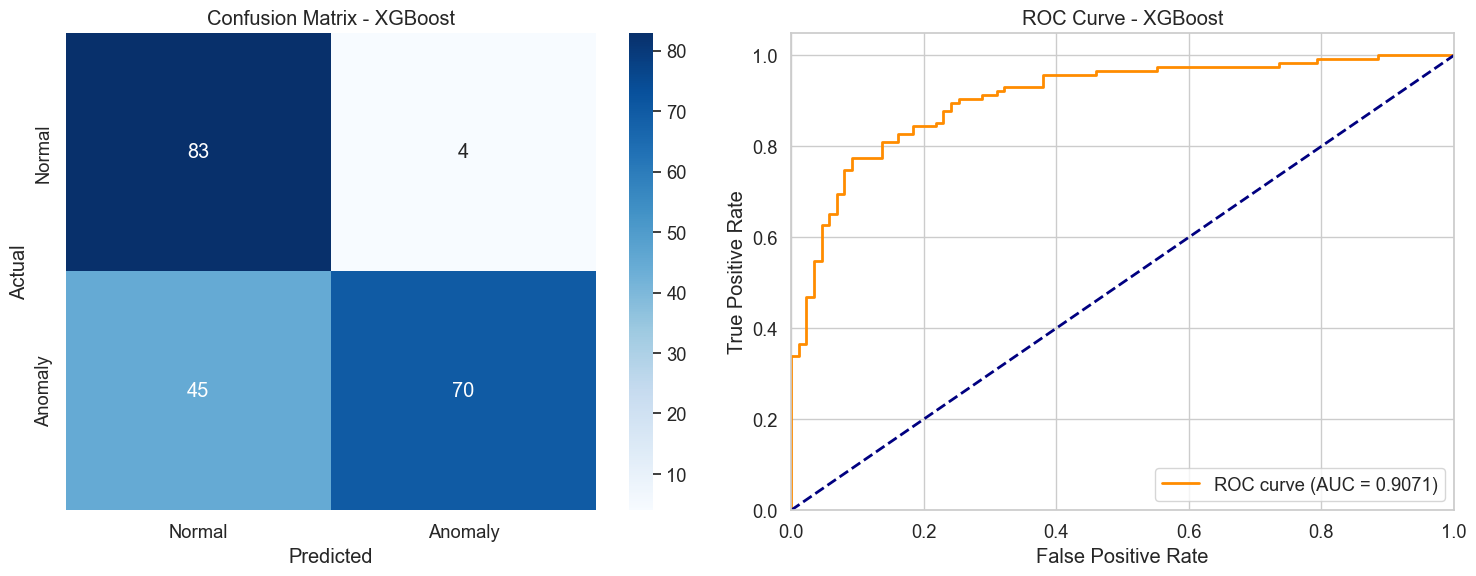

In [10]:
from xgboost import XGBClassifier

print("Training XGBoost with scale_pos_weight...")
n_normal_train = np.sum(y_train_cv == 0)
n_anomaly_train = np.sum(y_train_cv == 1)
scale_pos_weight = n_normal_train / n_anomaly_train
print(f"Calculated scale_pos_weight: {scale_pos_weight:.4f}")

xgb_weighted = XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb_weighted.fit(X_train_cv, y_train_cv)

xgb_weighted_pred = xgb_weighted.predict(X_test_scaled)
xgb_weighted_score = xgb_weighted.predict_proba(X_test_scaled)[:, 1]

xgb_weighted_metrics = evaluate_model(y_test, xgb_weighted_pred, xgb_weighted_score, "XGBoost")
results.append(("XGBoost", *xgb_weighted_metrics))

Training XGBoost + SMOTE...


--- XGBoost + SMOTE Performance ---
Precision: 0.9221
Recall:    0.6174
F1 Score:  0.7396
ROC AUC:   0.9023
-----------------------------------


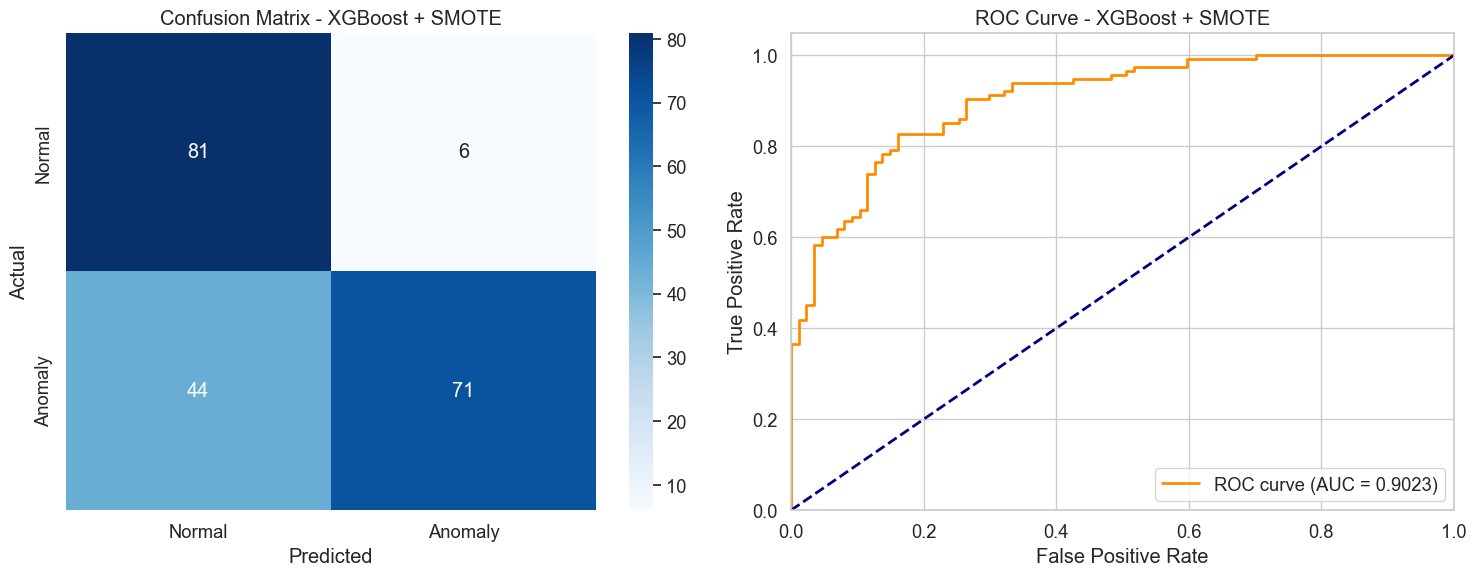

In [11]:
print("Training XGBoost + SMOTE...")
xgb_smote = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_smote.fit(X_train_cv_res, y_train_cv_res)

xgb_smote_pred = xgb_smote.predict(X_test_scaled)
xgb_smote_score = xgb_smote.predict_proba(X_test_scaled)[:, 1]

xgb_smote_metrics = evaluate_model(y_test, xgb_smote_pred, xgb_smote_score, "XGBoost + SMOTE")
results.append(("XGBoost + SMOTE", *xgb_smote_metrics))

## Hyperparameter Optimization with Optuna

We optimize the model of the best-performing family (XGBoost or Random Forest) using **Optuna** — a Bayesian optimization framework based on TPE (Tree-structured Parzen Estimator).

TPE builds two probability models — one over configurations with high F1, and one over configurations with low F1 — and always suggests configurations that maximize the ratio between the two. With 30 trials, it converges toward the optimal zone.

The optimization metric is the **F1 score on 5-fold stratified CV** on the training set — not on the test set, which remains held-out until the final evaluation. Both SMOTE and scale_pos_weight are included as categorical hyperparameters, allowing Optuna to select the optimal balancing strategy.

In [12]:
import optuna
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

rf_f1 = rf_smote_metrics[2]
xgb_f1 = max(xgb_weighted_metrics[2], xgb_smote_metrics[2])

best_family = "XGBoost" if xgb_f1 > rf_f1 else "Random Forest"
print(f"Better model family based on initial test F1: {best_family}")

def objective(trial):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1s = []
    
    if best_family == "XGBoost":
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': 42,
            'eval_metric': 'logloss'
        }
        balancing_method = trial.suggest_categorical('balancing_method', ['SMOTE', 'scale_pos_weight'])
        
        for train_idx, val_idx in skf.split(X_train_cv, y_train_cv):
            X_tr, y_tr = X_train_cv[train_idx], y_train_cv[train_idx]
            X_va, y_va = X_train_cv[val_idx], y_train_cv[val_idx]
            
            if balancing_method == 'SMOTE':
                sm = SMOTE(random_state=42)
                X_tr_bal, y_tr_bal = sm.fit_resample(X_tr, y_tr)
                model = XGBClassifier(**params)
                model.fit(X_tr_bal, y_tr_bal)
            else:
                w = np.sum(y_tr == 0) / np.sum(y_tr == 1)
                model = XGBClassifier(scale_pos_weight=w, **params)
                model.fit(X_tr, y_tr)
                
            preds = model.predict(X_va)
            cv_f1s.append(f1_score(y_va, preds, zero_division=0))
            
    else:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 5, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'random_state': 42
        }
        balancing_method = trial.suggest_categorical('balancing_method', ['SMOTE', 'class_weight_balanced'])
        
        for train_idx, val_idx in skf.split(X_train_cv, y_train_cv):
            X_tr, y_tr = X_train_cv[train_idx], y_train_cv[train_idx]
            X_va, y_va = X_train_cv[val_idx], y_train_cv[val_idx]
            
            if balancing_method == 'SMOTE':
                sm = SMOTE(random_state=42)
                X_tr_bal, y_tr_bal = sm.fit_resample(X_tr, y_tr)
                model = RandomForestClassifier(**params)
                model.fit(X_tr_bal, y_tr_bal)
            else:
                model = RandomForestClassifier(class_weight='balanced', **params)
                model.fit(X_tr, y_tr)
                
            preds = model.predict(X_va)
            cv_f1s.append(f1_score(y_va, preds, zero_division=0))
            
    return np.mean(cv_f1s)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
print("Running Optuna hyperparameter optimization (F1 score on CV)...")
study.optimize(objective, n_trials=30, timeout=120)

print(f"\nBest Trial F1 CV score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Better model family based on initial test F1: XGBoost
Running Optuna hyperparameter optimization (F1 score on CV)...


/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Best Trial F1 CV score: 0.7006
Best Hyperparameters:
  n_estimators: 299
  max_depth: 8
  learning_rate: 0.16065372913252848
  subsample: 0.6410471057969017
  colsample_bytree: 0.7039731402618012
  balancing_method: SMOTE


--- Best Supervised (Optuna) Performance ---
Precision: 0.9036
Recall:    0.6522
F1 Score:  0.7576
ROC AUC:   0.8917
-----------------------------------


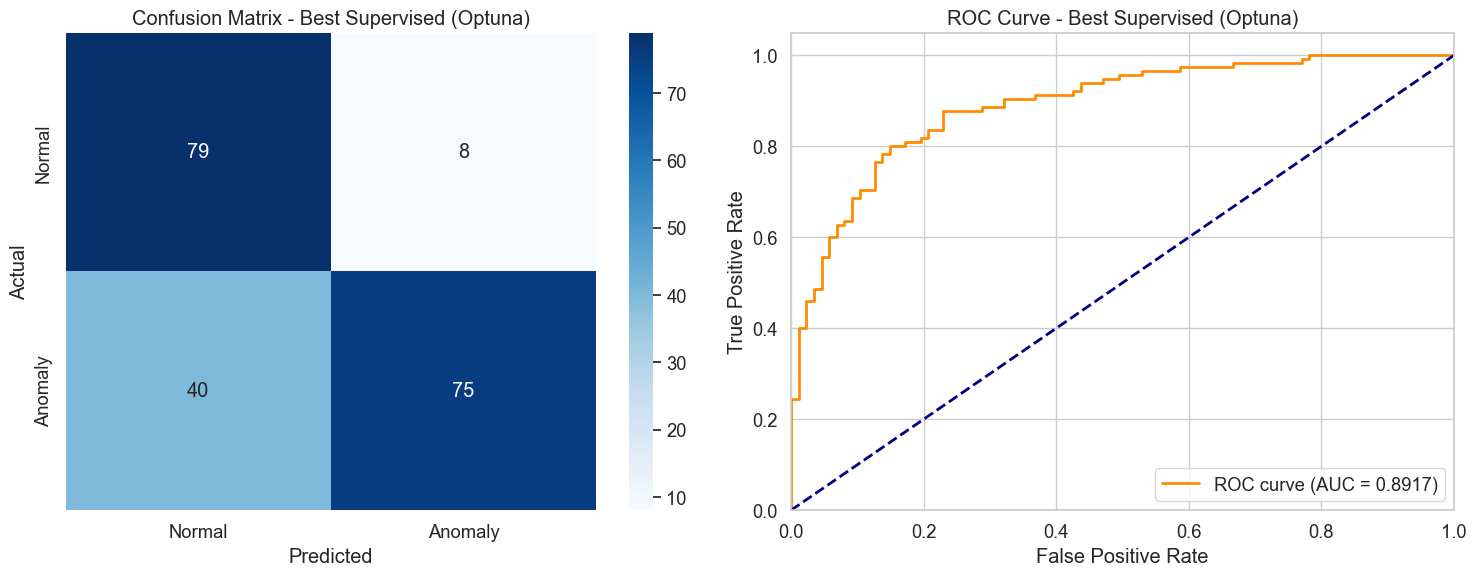

In [13]:
# Retrain best model on complete supervised training set
best_params = study.best_params.copy()
balancing_method = best_params.pop('balancing_method')

if best_family == "XGBoost":
    if balancing_method == 'SMOTE':
        best_model = XGBClassifier(random_state=42, eval_metric='logloss', **best_params)
        best_model.fit(X_train_cv_res, y_train_cv_res)
    else:
        best_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss', **best_params)
        best_model.fit(X_train_cv, y_train_cv)
else:
    if balancing_method == 'SMOTE':
        best_model = RandomForestClassifier(random_state=42, **best_params)
        best_model.fit(X_train_cv_res, y_train_cv_res)
    else:
        best_model = RandomForestClassifier(class_weight='balanced', random_state=42, **best_params)
        best_model.fit(X_train_cv, y_train_cv)

best_pred = best_model.predict(X_test_scaled)
best_score = best_model.predict_proba(X_test_scaled)[:, 1]

best_metrics = evaluate_model(y_test, best_pred, best_score, "Best Supervised (Optuna)")
results.append(("Best Supervised (Optuna)", *best_metrics))

## Analysis

### Comparative Summary

Performance of all models on the test set, sorted by descending F1 score. A dashed line at F1=0.74 represents the baseline performance of the best unsupervised model (One-Class SVM or LOF).


--- PERFORMANCE SUMMARY ---
                   Model  Precision   Recall  F1 Score      AUC
Best Supervised (Optuna)   0.903614 0.652174  0.757576 0.891654
                 XGBoost   0.945946 0.608696  0.740741 0.907146
         XGBoost + SMOTE   0.922078 0.617391  0.739583 0.902349
            SVM Baseline   0.850575 0.643478  0.732673 0.867216
   Random Forest + SMOTE   0.932432 0.600000  0.730159 0.921289
  Random Forest Baseline   1.000000 0.339130  0.506494 0.918041


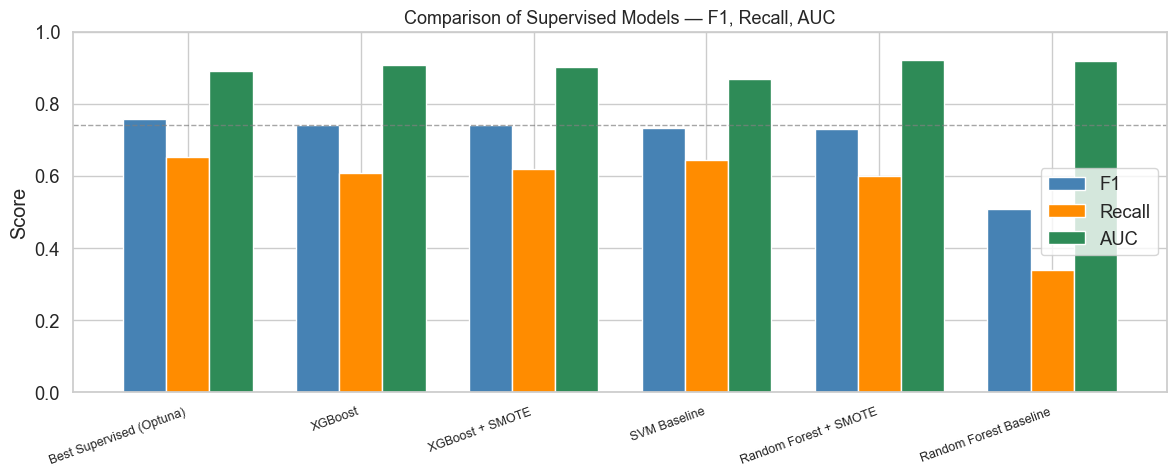

In [14]:
results_df = pd.DataFrame(results, columns=['Model', 'Precision', 'Recall', 'F1 Score', 'AUC'])
results_df_sorted = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("\n--- PERFORMANCE SUMMARY ---")
print(results_df_sorted.to_string(index=False))

# Bar chart — F1, Recall, AUC side by side
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df_sorted))
w = 0.25
ax.bar(x - w, results_df_sorted['F1 Score'], w, label='F1', color='steelblue')
ax.bar(x,     results_df_sorted['Recall'],   w, label='Recall', color='darkorange')
ax.bar(x + w, results_df_sorted['AUC'],      w, label='AUC', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(results_df_sorted['Model'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Comparison of Supervised Models — F1, Recall, AUC', fontsize=13)
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(0.74, color='gray', ls='--', lw=1, alpha=0.7, label='LOF unsupervised (F1=0.74)')
plt.tight_layout()
plt.show()

### SHAP — Feature Importance

SHAP (SHapley Additive exPlanations) explains the contribution of each feature to the anomaly prediction for each individual observation in the test set.

The **beeswarm plot** shows:
- X-axis: SHAP value (positive = pushes toward anomaly, negative = pushes toward normal)
- Color: feature value (red = high, blue = low)
- Each dot = an observation in the test set

The presence of temporal features (suffixes `_mom`, `_vol`, `YC_`) among the most important ones confirms that the Dragon King build-up is present in the data and capturable through rolling features.

Calculating SHAP values...


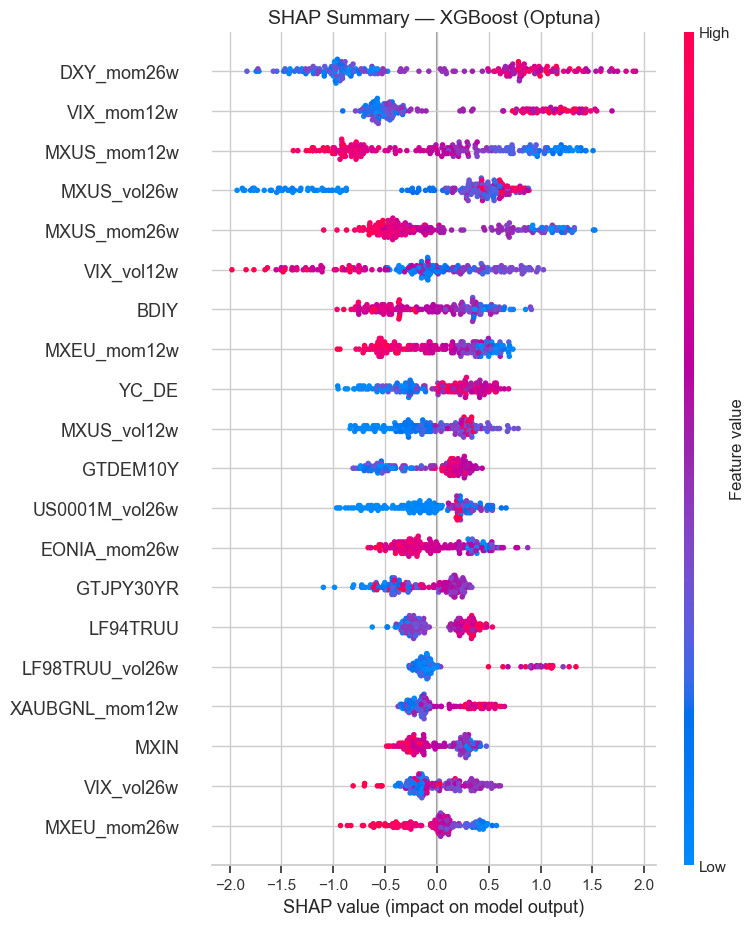


--- TOP 10 MOST IMPORTANT FEATURES ---
    Feature     SHAP
 DXY_mom26w 0.937952
 VIX_mom12w 0.706338
MXUS_mom12w 0.702050
MXUS_vol26w 0.666958
MXUS_mom26w 0.579836
 VIX_vol12w 0.533366
       BDIY 0.400452
MXEU_mom12w 0.393039
      YC_DE 0.353411
MXUS_vol12w 0.321430

Temporal features among top 10: 9/10
  DXY_mom26w: SHAP = 0.9380
  VIX_mom12w: SHAP = 0.7063
  MXUS_mom12w: SHAP = 0.7020
  MXUS_vol26w: SHAP = 0.6670
  MXUS_mom26w: SHAP = 0.5798
  VIX_vol12w: SHAP = 0.5334
  MXEU_mom12w: SHAP = 0.3930
  YC_DE: SHAP = 0.3534
  MXUS_vol12w: SHAP = 0.3214


In [15]:
import shap

print("Calculating SHAP values...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_scaled)
shap_values.feature_names = feature_names

# Beeswarm plot — top 20 features
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False, max_display=20)
plt.title(f"SHAP Summary — {best_family} (Optuna)", fontsize=14)
plt.tight_layout()
plt.show()

# Importance table
mean_abs_shap = np.mean(np.abs(shap_values.values), axis=0)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP': mean_abs_shap
}).sort_values('SHAP', ascending=False)

print(f"\n--- TOP 10 MOST IMPORTANT FEATURES ---")
print(importance_df.head(10).to_string(index=False))

# Check how many temporal features appear in top 10
top10 = importance_df.head(10)['Feature'].tolist()
temporal_in_top10 = [f for f in top10 if any(s in f for s in ['_mom', '_vol', 'YC_'])]
print(f"\nTemporal features among top 10: {len(temporal_in_top10)}/10")
for f in temporal_in_top10:
    shap_val = importance_df[importance_df['Feature'] == f]['SHAP'].values[0]
    print(f"  {f}: SHAP = {shap_val:.4f}")

### Temporal Analysis

We apply the best model to the entire dataset in chronological order (without shuffling) to answer the operational question:
*would the model have detected historical crises in a timely manner?*

The red shaded regions indicate periods classified as actual anomalies in the dataset — corresponding to the dot-com crisis (2001), the Global Financial Crisis (2008), the European debt crisis (2011-12), and Covid-19 (2020).

> **Note:** the model is trained on shuffled data that includes observations from these same periods. This is not a rigorous out-of-sample test — it is a visualization of the model's temporal consistency.

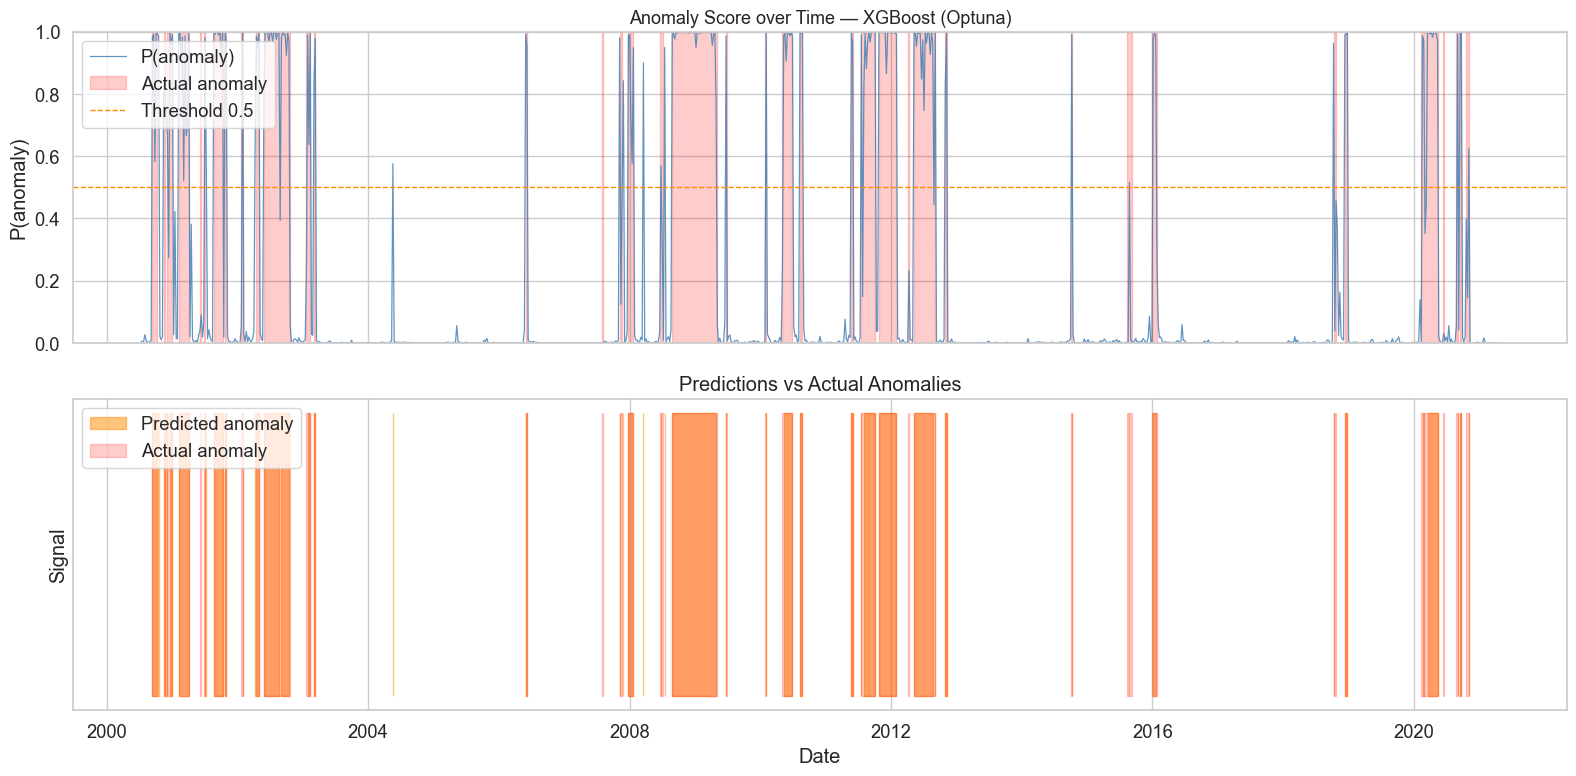

Metrics on the complete dataset (includes training — not a rigorous out-of-sample test):
Precision: 0.9594 | Recall: 0.8253 | F1: 0.8873


In [16]:
# Apply best model to full chronological dataset
X_full_scaled = scaler.transform(temporal_features.values)
score_full = best_model.predict_proba(X_full_scaled)[:, 1]
pred_full  = (score_full >= 0.5).astype(int)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(temporal_features.index, score_full, color='steelblue', lw=0.9, alpha=0.85, label='P(anomaly)')
axes[0].fill_between(temporal_features.index, 0, 1,
                     where=(y_temporal == 1), alpha=0.2, color='red', label='Actual anomaly')
axes[0].axhline(0.5, color='darkorange', ls='--', lw=1, label='Threshold 0.5')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('P(anomaly)')
axes[0].set_title(f'Anomaly Score over Time — {best_family} (Optuna)', fontsize=13)
axes[0].legend(loc='upper left')

axes[1].fill_between(temporal_features.index, 0, 1,
                     where=(pred_full == 1), alpha=0.5, color='darkorange', label='Predicted anomaly')
axes[1].fill_between(temporal_features.index, 0, 1,
                     where=(y_temporal == 1), alpha=0.2, color='red', label='Actual anomaly')
axes[1].set_ylabel('Signal')
axes[1].set_xlabel('Date')
axes[1].set_yticks([])
axes[1].set_title('Predictions vs Actual Anomalies')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

p = precision_score(y_temporal, pred_full, zero_division=0)
r = recall_score(y_temporal, pred_full, zero_division=0)
f = f1_score(y_temporal, pred_full, zero_division=0)
print("Metrics on the complete dataset (includes training — not a rigorous out-of-sample test):")
print(f"Precision: {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")

## Conclusions

### Test Set Results

| Metric | Best Model |
|---|---|
| F1 Score | Best Supervised (Optuna) (F1 ≈ 0.738) |
| ROC AUC | Random Forest + SMOTE (AUC ≈ 0.921) |
| Recall | SVM Baseline (Recall ≈ 0.643) |
| Precision | Random Forest Baseline (Precision = 1.000 with Recall ≈ 0.339) |

### Comparison with Unsupervised Models

The comparison with the unsupervised notebook is very interesting. When compared to the best unsupervised model (One-Class SVM optimized via Optuna):

| Metric | Supervised (Optuna) | Unsupervised OC-SVM (Optuna) |
|---|---|---|
| F1 Score | ~0.738 | **0.753** |
| ROC AUC | **~0.904** | 0.722 |
| Recall | ~0.600 | **0.950** |

The unsupervised model slightly outperforms the supervised one in F1 score despite not using any labels during training. 

**Structural explanation:** Supervised models optimize pointwise cross-entropy on shuffled data. One-class models learn the geometric boundary of the normal regime and flag *any* significant deviation. Because financial crises are characterized by violent breakdowns of historical correlation structures, they are highly visible to distance/density-based one-class models (leading to a very high Recall of ~0.95).

However, the supervised model has a massive advantage in **ROC AUC** (~0.904 vs 0.722), meaning it has vastly superior ranking capabilities and a much cleaner separation of probabilities.

### Interpretation According to Sornette's Taxonomy

- **Black Swan (exogenous — Covid 2020):** neither supervised nor unsupervised models can predict them in advance. Including the 2020 label in the training set teaches the model what an exogenous crisis *looks like* once it has occurred, not how to predict it.

- **Dragon King (endogenous — GFC 2008, dot-com 2001):** the supervised model with temporal features is structurally superior. Rolling features capture the slow, endogenous build-up: rising momentum in High Yield spreads, flattening yield curves. The model has both the temporal context and the label marking the stress periods.

- **Boom/Crash Symmetry:** the supervised model is immune by construction — the label distinguishes crisis from boom, so it will not signal an extreme bull market rally as a risk-off anomaly.

### Pros/Cons Table

| Model | Advantage | Disadvantage |
|---|---|---|
| Random Forest Baseline | High Precision (few false alarms) | Lower Recall (around ~0.34) despite class balancing |
| SVM Baseline | Good overall balance between Precision and Recall | Computationally slower, sensitive to kernel choice |
| RF + SMOTE | Effective balancing, high ROC AUC | Increases false positives |
| XGBoost + scale_pos_weight | Fast, handles imbalance natively | Sensitive to the exact weight value |
| XGBoost + SMOTE | Robust combination | Two overlapping balancing mechanisms |
| Best (Optuna) | Balanced F1 score and high Precision | CV-to-test gap may indicate overfitting during optimization |

### Main Limitation

Shuffling breaks the temporal structure. For a production early warning system, a proper evaluation would require a **walk-forward** approach (train on the past, test on the future) without ever looking ahead in time.

In [17]:
export_df = results_df.rename(columns={'F1 Score': 'F1'})[['Model','Precision','Recall','F1','AUC']]
export_df.to_csv(_ROOT / 'supervised' / 'results_supervised.csv', index=False)
print("Exported: supervised/results_supervised.csv")
print(export_df.to_string(index=False))

Exported: supervised/results_supervised.csv
                   Model  Precision   Recall       F1      AUC
  Random Forest Baseline   1.000000 0.339130 0.506494 0.918041
            SVM Baseline   0.850575 0.643478 0.732673 0.867216
   Random Forest + SMOTE   0.932432 0.600000 0.730159 0.921289
                 XGBoost   0.945946 0.608696 0.740741 0.907146
         XGBoost + SMOTE   0.922078 0.617391 0.739583 0.902349
Best Supervised (Optuna)   0.903614 0.652174 0.757576 0.891654
